In [1]:
# ============================================================
# Cella P1: Import di tutte le librerie necessarie
# per il preprocessing e per i modelli ML.
# Importiamo tutto qui così le celle successive sono pulite.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

os.makedirs('grafici', exist_ok=True)
sns.set_theme(style='whitegrid', palette='husl')

print("Librerie importate correttamente.")

Librerie importate correttamente.


In [2]:
# ============================================================
# Cella P2: Carichiamo il dataset pulito prodotto dall'EDA.
# Questo file non ha valori mancanti — è quello su cui
# abbiamo già chiamato dropna().
# ============================================================

df = pd.read_csv('data/dataset_pulito.csv')

print(f"Dataset caricato: {df.shape[0]} righe × {df.shape[1]} colonne")
print(f"\nColonne presenti:")
for col in df.columns:
    dtype = df[col].dtype
    n_unici = df[col].nunique()
    print(f"  {col:<35} tipo: {str(dtype):<10} valori unici: {n_unici}")

print(f"\nValori mancanti: {df.isnull().sum().sum()} ✓")

Dataset caricato: 6378 righe × 20 colonne

Colonne presenti:
  Hours_Studied                       tipo: int64      valori unici: 41
  Attendance                          tipo: int64      valori unici: 41
  Parental_Involvement                tipo: str        valori unici: 3
  Access_to_Resources                 tipo: str        valori unici: 3
  Extracurricular_Activities          tipo: str        valori unici: 2
  Sleep_Hours                         tipo: int64      valori unici: 7
  Previous_Scores                     tipo: int64      valori unici: 51
  Motivation_Level                    tipo: str        valori unici: 3
  Internet_Access                     tipo: str        valori unici: 2
  Tutoring_Sessions                   tipo: int64      valori unici: 9
  Family_Income                       tipo: str        valori unici: 3
  Teacher_Quality                     tipo: str        valori unici: 3
  School_Type                         tipo: str        valori unici: 2
  Peer_Influe

In [3]:
# ============================================================
# Cella P3: Encoding delle variabili categoriche
# ============================================================
#
# PERCHÉ LabelEncoder?
# I modelli ML come la regressione logistica o i decision tree
# eseguono calcoli matematici. "male" e "female" non possono
# essere sommati o moltiplicati. Dopo l'encoding:
#   "female" → 0
#   "male"   → 1
# Il modello può ora fare calcoli su questi numeri.
#
# ATTENZIONE: LabelEncoder funziona bene per variabili con
# 2 categorie (binarie) o per gli alberi decisionali.
# Per variabili con molte categorie ordinate, è comunque
# una scelta accettabile a livello universitario.
# ============================================================

df_encoded = df.copy()  # lavoriamo sempre su una copia

le = LabelEncoder()

# Salviamo un dizionario con la mappatura, per consultarla dopo
mappatura_encoding = {}

cat_cols = df_encoded.select_dtypes(include='object').columns.tolist()
print(f"Colonne da codificare ({len(cat_cols)}): {cat_cols}\n")

for col in cat_cols:
    valori_originali = df_encoded[col].unique().tolist()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    valori_codificati = df_encoded[col].unique().tolist()
    
    # Crea dizionario originale → codice
    le_temp = LabelEncoder().fit(df[col])
    mappatura = dict(zip(le_temp.classes_, le_temp.transform(le_temp.classes_)))
    mappatura_encoding[col] = mappatura
    
    print(f"✓ {col}")
    print(f"  Mappatura: {mappatura}")

print("\n=== DATASET DOPO L'ENCODING ===")
print(f"Colonne di tipo 'object' rimaste: {df_encoded.select_dtypes(include='object').shape[1]}")
print(f"Tutte le colonne sono ora numeriche: {all(df_encoded.dtypes != 'object')}")
df_encoded.head()

Colonne da codificare (13): ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

✓ Parental_Involvement
  Mappatura: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
✓ Access_to_Resources
  Mappatura: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
✓ Extracurricular_Activities
  Mappatura: {'No': np.int64(0), 'Yes': np.int64(1)}
✓ Motivation_Level
  Mappatura: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
✓ Internet_Access
  Mappatura: {'No': np.int64(0), 'Yes': np.int64(1)}
✓ Family_Income
  Mappatura: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
✓ Teacher_Quality
  Mappatura: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
✓ School_Type
  Mappatura: {'Private': np.int64(0), 'Public

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1,67
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0,61
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1,74
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,1,71
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,0,70


Mediana di Exam_Score: 67.0
Soglia adottata: punteggio >= 67.0 → Target = 1 (High Performance)
                 punteggio <  67.0 → Target = 0 (Low Performance)

High Performance (Target=1): 3610 (56.6%)
Low Performance  (Target=0): 2768  (43.4%)


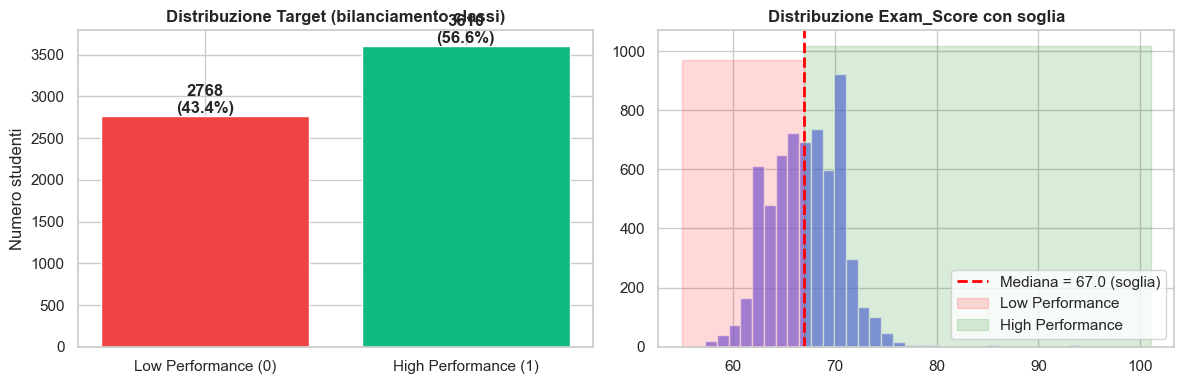

In [4]:
# ============================================================
# Cella P4: Creazione della variabile Target
# ============================================================
#
# PERCHÉ LA MEDIANA come soglia?
# Con soglia fissa a 60 il 99% degli studenti risultava
# promosso → dataset completamente sbilanciato → il modello
# impara solo a predire "sempre 1" e ottiene comunque il 99%.
# La mediana risolve questo garantendo ~50% per classe.
#
# PERCHÉ High/Low Performance invece di Promosso/Bocciato?
# Non stiamo giudicando se uno studente è sufficiente in
# senso assoluto: stiamo confrontando le performance relative
# degli studenti tra loro. "High" = sopra la metà del gruppo,
# "Low" = sotto la metà del gruppo.
#
# La formula (df_encoded['Exam_Score'] >= median_score)
# produce una serie di True/False (booleani).
# .astype(int) converte True→1 e False→0.
# ============================================================

# Identifica la colonna del punteggio principale
score_col = 'Exam_Score'  # adatta se il nome è diverso nel tuo dataset
if score_col not in df_encoded.columns:
    # Cerca automaticamente
    candidates = [c for c in df_encoded.columns if 'score' in c.lower()]
    score_col = candidates[0] if candidates else None
    print(f"Colonna punteggio trovata automaticamente: '{score_col}'")

# Calcola la mediana
median_score = df_encoded[score_col].median()
print(f"Mediana di {score_col}: {median_score}")
print(f"Soglia adottata: punteggio >= {median_score} → Target = 1 (High Performance)")
print(f"                 punteggio <  {median_score} → Target = 0 (Low Performance)")

# Crea la colonna Target
df_encoded['Target'] = (df_encoded[score_col] >= median_score).astype(int)

# Analisi del bilanciamento
n_high = df_encoded['Target'].sum()
n_low  = len(df_encoded) - n_high
print(f"\nHigh Performance (Target=1): {n_high} ({n_high/len(df_encoded)*100:.1f}%)")
print(f"Low Performance  (Target=0): {n_low}  ({n_low/len(df_encoded)*100:.1f}%)")

# Grafico distribuzione target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Low Performance (0)', 'High Performance (1)'], [n_low, n_high],
           color=['#ef4444', '#10b981'], edgecolor='white')
axes[0].set_title('Distribuzione Target (bilanciamento classi)', fontweight='bold')
axes[0].set_ylabel('Numero studenti')
for i, v in enumerate([n_low, n_high]):
    axes[0].text(i, v+30, f'{v}\n({v/len(df_encoded)*100:.1f}%)',
                ha='center', fontweight='bold')

# Distribuzione Exam_Score con linea della mediana
axes[1].hist(df_encoded[score_col], bins=40, color='#6366f1', alpha=0.7, edgecolor='white')
axes[1].axvline(median_score, color='red', linestyle='--', linewidth=2,
               label=f'Mediana = {median_score} (soglia)')
axes[1].fill_betweenx([0, axes[1].get_ylim()[1] if axes[1].get_ylim()[1]>0 else 500],
                      df_encoded[score_col].min(), median_score,
                      alpha=0.15, color='red', label='Low Performance')
axes[1].fill_betweenx([0, axes[1].get_ylim()[1] if axes[1].get_ylim()[1]>0 else 500],
                      median_score, df_encoded[score_col].max(),
                      alpha=0.15, color='green', label='High Performance')
axes[1].set_title(f'Distribuzione {score_col} con soglia', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('grafici/distribuzione_target.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# ============================================================
# Cella P5: Selezione delle feature (X) e del target (y)
# ============================================================
#
# X = tutte le colonne tranne Exam_Score e Target
#     (sono le informazioni che conosci PRIMA dell'esame)
#
# y = Target (è quello che vuoi predire DOPO l'esame)
#
# Escludere Exam_Score è fondamentale!
# Se lo includessi in X, il modello vedrebbe:
#   "Exam_Score=72, Target=1" → impara che 72 ≥ mediana = 1
# Non sta imparando nulla di utile: sta solo imparando la
# regola matematica che abbiamo usato noi per creare Target.
# Questo si chiama "data leakage" ed è un errore grave.
# ============================================================

# Colonne da escludere da X
cols_escluse = [score_col, 'Target']
cols_escluse = [c for c in cols_escluse if c in df_encoded.columns]

# Feature columns
feature_cols = [c for c in df_encoded.columns if c not in cols_escluse]

X = df_encoded[feature_cols]
y = df_encoded['Target']

print("=== SEPARAZIONE X e y ===")
print(f"\nFeature usate come input X ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    dtype_orig = df[col].dtype if col in df.columns else 'encoded'
    print(f"  {i:2}. {col:<35} (tipo originale: {dtype_orig})")

print(f"\nColonne escluse: {cols_escluse}")
print(f"\nShape X: {X.shape}  (righe × feature)")
print(f"Shape y: {y.shape}  (righe)")
print(f"\nDistribuzione target y:\n{y.value_counts().to_string()}")

=== SEPARAZIONE X e y ===

Feature usate come input X (19):
   1. Hours_Studied                       (tipo originale: int64)
   2. Attendance                          (tipo originale: int64)
   3. Parental_Involvement                (tipo originale: str)
   4. Access_to_Resources                 (tipo originale: str)
   5. Extracurricular_Activities          (tipo originale: str)
   6. Sleep_Hours                         (tipo originale: int64)
   7. Previous_Scores                     (tipo originale: int64)
   8. Motivation_Level                    (tipo originale: str)
   9. Internet_Access                     (tipo originale: str)
  10. Tutoring_Sessions                   (tipo originale: int64)
  11. Family_Income                       (tipo originale: str)
  12. Teacher_Quality                     (tipo originale: str)
  13. School_Type                         (tipo originale: str)
  14. Peer_Influence                      (tipo originale: str)
  15. Physical_Activity           

In [8]:
# ============================================================
# Cella P6: Divisione Training / Test set
# ============================================================
#
# test_size=0.20 → 20% dei dati va nel test set, 80% nel train
# random_state=42 → "seme" per la casualità. Garantisce che
#   ogni volta che esegui questo codice ottieni la STESSA
#   divisione. Senza questo, ogni esecuzione darebbe risultati
#   diversi e non riproducibili.
# stratify=y → mantiene le stesse proporzioni di 0 e 1 sia
#   nel train che nel test. Senza stratify, potrebbe capitare
#   che il test abbia quasi solo High Performance e il train quasi
#   solo Low Performance → risultati falsati.
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=== RISULTATO DELLO SPLIT ===")
print(f"\nTraining set:")
print(f"  Campioni:          {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.0f}% del totale)")
print(f"  High Performance:  {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"  Low Performance:   {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")

print(f"\nTest set:")
print(f"  Campioni:          {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.0f}% del totale)")
print(f"  High Performance:  {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print(f"  Low Performance:   {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)")

print("\n✓ Le percentuali di High/Low Performance sono simili nei due set (stratify ha funzionato)")

=== RISULTATO DELLO SPLIT ===

Training set:
  Campioni:          5102 (80% del totale)
  High Performance:  2888 (56.6%)
  Low Performance:   2214 (43.4%)

Test set:
  Campioni:          1276 (20% del totale)
  High Performance:  722 (56.6%)
  Low Performance:   554 (43.4%)

✓ Le percentuali di High/Low Performance sono simili nei due set (stratify ha funzionato)


In [7]:
# ============================================================
# Cella P7: Normalizzazione con StandardScaler
# ============================================================
#
# StandardScaler trasforma ogni valore x in:
#   x_scalato = (x - media) / deviazione_standard
#
# Risultato: ogni colonna avrà media=0 e std=1
#
# fit_transform(X_train): calcola media e std dal training set,
#                         poi applica la trasformazione
# transform(X_test):      usa media e std già calcolate sul train,
#                         NON ricalcola sul test (regola fondamentale!)
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # ← fit + transform sul train
X_test_scaled  = scaler.transform(X_test)         # ← solo transform sul test

# Converti in DataFrame per visualizzazione più leggibile
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=feature_cols)

print("=== EFFETTO DELLA NORMALIZZAZIONE (sul training set) ===")
print(f"\n{'Feature':<30} {'Media prima':>12} {'Media dopo':>12} {'Std prima':>10} {'Std dopo':>10}")
print("-"*80)
for col in feature_cols:
    m_prima = X_train[col].mean()
    s_prima = X_train[col].std()
    m_dopo  = X_train_scaled_df[col].mean()
    s_dopo  = X_train_scaled_df[col].std()
    print(f"{col:<30} {m_prima:>12.3f} {m_dopo:>12.3f} {s_prima:>10.3f} {s_dopo:>10.3f}")

print("\n✓ Dopo la normalizzazione tutte le feature hanno media ≈ 0 e std ≈ 1")

=== EFFETTO DELLA NORMALIZZAZIONE (sul training set) ===

Feature                         Media prima   Media dopo  Std prima   Std dopo
--------------------------------------------------------------------------------
Hours_Studied                        19.972       -0.000      5.975      1.000
Attendance                           80.067        0.000     11.571      1.000
Parental_Involvement                  1.218       -0.000      0.867      1.000
Access_to_Resources                   1.205        0.000      0.870      1.000
Extracurricular_Activities            0.597       -0.000      0.491      1.000
Sleep_Hours                           7.032       -0.000      1.464      1.000
Previous_Scores                      74.955        0.000     14.460      1.000
Motivation_Level                      1.308        0.000      0.782      1.000
Internet_Access                       0.926        0.000      0.262      1.000
Tutoring_Sessions                     1.493       -0.000      1.233    

In [9]:
# ============================================================
# Cella P8: Salvataggio dei dati preprocessati
# ============================================================

# Salva training e test set (non scalati — per eventuali modelli basati su alberi)
X_train.to_csv('data/X_train.csv', index=False)
X_test.to_csv('data/X_test.csv',  index=False)
y_train.to_csv('data/y_train.csv', index=False)
y_test.to_csv('data/y_test.csv',  index=False)

# Salva training e test set scalati (per modelli lineari)
X_train_scaled_df.to_csv('data/X_train_scaled.csv', index=False)
X_test_scaled_df.to_csv('data/X_test_scaled.csv',  index=False)

# Salva anche il dataset encodato completo
df_encoded.to_csv('data/dataset_encoded.csv', index=False)

print("=== FILE SALVATI ===")
for f in ['X_train.csv', 'X_test.csv', 'y_train.csv', 'y_test.csv',
          'X_train_scaled.csv', 'X_test_scaled.csv', 'dataset_encoded.csv']:
    percorso = f'data/{f}'
    size_kb = os.path.getsize(percorso) // 1024
    print(f"  ✓ {percorso:<35} ({size_kb} KB)")

print("\n=== RIEPILOGO PREPROCESSING ===")
print(f"Feature utilizzate:      {len(feature_cols)}")
print(f"Training samples:        {X_train.shape[0]}")
print(f"Test samples:            {X_test.shape[0]}")
print(f"Colonne categoriche:     {len(cat_cols)} (ora tutte numeriche)")
print(f"Normalizzazione:         StandardScaler (media=0, std=1)")
print(f"Target: mediana Exam_Score = {median_score} → 1 (High Performance) se >=, 0 (Low Performance) se <")

=== FILE SALVATI ===
  ✓ data/X_train.csv                    (209 KB)
  ✓ data/X_test.csv                     (52 KB)
  ✓ data/y_train.csv                    (14 KB)
  ✓ data/y_test.csv                     (3 KB)
  ✓ data/X_train_scaled.csv             (1857 KB)
  ✓ data/X_test_scaled.csv              (464 KB)
  ✓ data/dataset_encoded.csv            (293 KB)

=== RIEPILOGO PREPROCESSING ===
Feature utilizzate:      19
Training samples:        5102
Test samples:            1276
Colonne categoriche:     13 (ora tutte numeriche)
Normalizzazione:         StandardScaler (media=0, std=1)
Target: mediana Exam_Score = 67.0 → 1 (High Performance) se >=, 0 (Low Performance) se <
